# Fundamentos de Manipulação de Imagens

## Conceitos fundamentais utilizando a biblioteca OpenCV.

**Principais tópicos abordados:**

- Leitura e exibição de imagens;
- Conversão entre RGB e BGR;
- Conversão para escala de cinza;
- Manipulação direta de pixels;
- Regiões de interesse (ROI);
- Extração de propriedades das imagens;
- Simulação de detecção facial utilizando bounding boxes.

In [1]:
import cv2
import numpy                       as np
from matplotlib      import pyplot as plt
from IPython.display import Image

### 1. Carregue a imagem 'frutas.jpg'

In [2]:
# Carregar uma imagem
path_pasta_imagem = '../data/imagem/'
image = cv2.imread(path_pasta_imagem+'imagem_frutas.jpg')

# Verificar se a imagem foi carregada corretamente
if image is None:
    print("Imagem não encontrada.")
else:
    print("Imagem carregada com sucesso.")

Imagem carregada com sucesso.


### 2. Exiba a imagem carregada em uma janela chamada 'Imagem Original'

In [3]:
# Exibir imagem
cv2.imshow('Imagem Original', image)
# aguarda digitar a letra q para fechar
cv2.waitKey(0)
# fecha todas as janelas
cv2.destroyAllWindows()

### 3. Salve a imagem com o nome 'frutas_copia.jpg'

In [4]:
# Salvar a imagem com nome "frutas_copia.jpg"
sucesso = cv2.imwrite('frutas_copia.jpg',image)

# Verifica se a imagem foi salva com sucesso
if sucesso:
    print("Imagem salva com sucesso.")
else:
    print("Erro ao salvar a imagem.")

Imagem salva com sucesso.


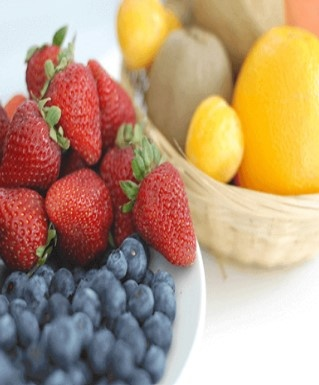

In [5]:
# Imagem salva na raiz
Image('frutas_copia.jpg')

### 4. Converta a imagem de BGR para RGB e exiba

In [6]:
# Converter imagem de BGR para RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

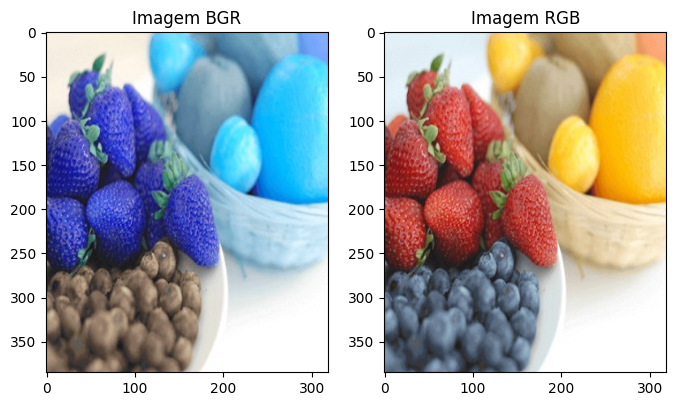

In [7]:
# exibindo imagens nos padrões BGR e RGB com a biblioteca matplotlib
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8,5))
ax[0].imshow(image)
ax[0].set_title('Imagem BGR')
ax[1].imshow(image_rgb)
ax[1].set_title('Imagem RGB')
plt.show()

### 5. Converta a imagem original para escala de cinza e exiba

In [8]:
# Converter imagem de BGR para escala de cinza
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Exibir imagem com open cv
cv2.imshow('Imagem Convertida',image_gray)
# aguarda até apertar a letra q
cv2.waitKey(0)
# fecha as janelas abertas
cv2.destroyAllWindows()

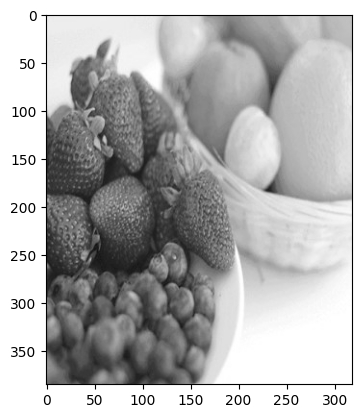

In [9]:
# converter para rgb e exibir com matplotlib
img_rgb_gray = cv2.cvtColor(image_gray,cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb_gray)

### 6. Crie uma função que imprima as seguintes informações de uma imagem:
* Shape (dimensões)
* Tipo do array
* Quantidade total de pixels
* Valor máximo e mínimo dos pixels

Aplique a função na imagem original e na imagem em escala de cinza.

In [10]:
def print_info_image(image):
    
    shape = image.shape
    image_dtype = image.dtype
    total_pixels = image.size
    max_value = np.max(image)
    min_value = np.min(image)

    print(f"Dimensões da imagem: {shape}")
    print(f"Tipo de dado: {image_dtype}")
    print(f"Número total de pixels: {total_pixels}")
    print(f"Valor máximo: {max_value}")
    print(f"Valor mínimo: {min_value}")

In [11]:
print("Image Original")
print_info_image(image = image)
print()
print("Image Escala de Cinza")
print_info_image(image = image_gray)    

Image Original
Dimensões da imagem: (385, 319, 3)
Tipo de dado: uint8
Número total de pixels: 368445
Valor máximo: 255
Valor mínimo: 0

Image Escala de Cinza
Dimensões da imagem: (385, 319)
Tipo de dado: uint8
Número total de pixels: 122815
Valor máximo: 255
Valor mínimo: 17


### 7. Altere os valores dos pixels da imagem pixel

* Altere o pixel na posição (5, 6) para vermelho puro
* Altere o pixel na posição (2, 2) para verde puro 
* Altere o pixel na posição (9, 3) para amarelo


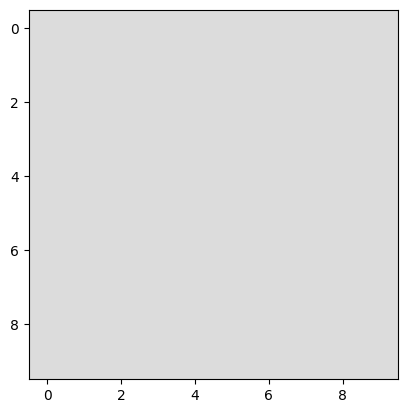

In [12]:
# gerando a imagem inicial
pixels = np.ones((10, 10, 3), dtype=np.uint8) * 220

# exibindo a imagem inicial
plt.imshow(pixels);

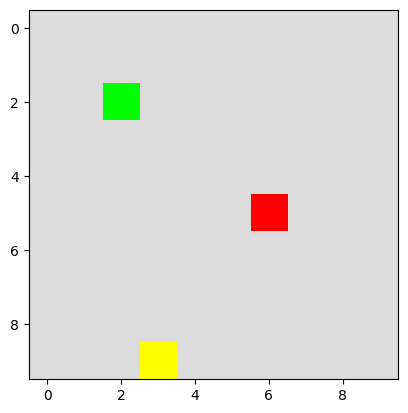

In [13]:
# Manipuilação de pixels

# alterando os pixels padrão BGR
pixels[5,6] = (0,0,255)
pixels[2,2] = (0,255,0)
pixels[9,3] = (0,255,255)

# Exibir imagem por meio do matplotlib
# converter imagem BGR para RGB
img_rgb = cv2.cvtColor(pixels,cv2.COLOR_BGR2RGB)
#exibir imagem
plt.imshow(img_rgb);

### 8. Recorte uma região de interesse (ROI) da imagem original

Recorte um quadrado de 100x200 pixels a partir da posição (100, 100)

In [14]:
# Região de Interesse (ROI)
roi = image[100:200,100:300]

# Exibir imagem original e ROI
cv2.imshow('Imagem Original', image)
cv2.imshow('ROI', roi)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [15]:
# converter para rgb e exibir com matplotlib
img_roi_rgb = cv2.cvtColor(roi,cv2.COLOR_BGR2RGB)
img_rgb = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

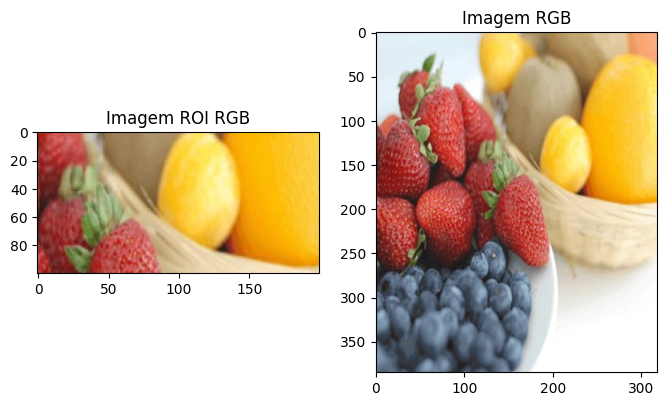

In [16]:
# exibindo imagens no padrão RGB com a biblioteca matplotlib
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8,5))
ax[0].imshow(img_roi_rgb)
ax[0].set_title('Imagem ROI RGB')
ax[1].imshow(img_rgb)
ax[1].set_title('Imagem RGB')
plt.show()

### 9. Modificação Parcial de uma ROI

**Objetivo:**

Praticar a manipulação de regiões específicas em imagens usando operações de slicing e alteração de valores de pixels.

**Contexto:**

Com a `roi` obtida acima, sua tarefa é:

* Divida a ROI horizontalmente em duas metades:

    * Metade esquerda (50% da largura): Preencha com verde puro (BGR: (0, 255, 0)).
    * Metade direita (50% da largura):
        * Divida verticalmente em duas partes:
            * Parte superior (50% da altura): Preencha com amarelo puro (BGR: (0, 255, 255)).
            * Parte inferior (50% da altura): Preencha com azul puro (BGR: (255, 0, 0)).

* Exiba os resultados:

    * A ROI modificada (com as 3 cores aplicadas).
    * A imagem original com a ROI modificada reinserida.

Requisitos:

* Não modifique a imagem original diretamente (trabalhe em uma cópia da ROI).
* Use slicing avançado para selecionar as sub-regiões corretas.
* Defina as cores corretamente no formato BGR.


Dicas:
* A ROI tem dimensões (altura, largura) = (100, 200).
* Para selecionar metade da largura: roi[:, :largura//2] (esquerda) ou roi[:, largura//2:] (direita).
* Para selecionar metade da altura: roi[:altura//2, :] (superior) ou roi[altura//2:, :] (inferior).

In [17]:
# criando uma copia da imagem roi em roi_modificada
ROI_modificada = roi.copy()

# Obtendo as dimensões da ROI
altura, largura, _ = ROI_modificada.shape
lagura_50 = largura//2
altura_50 = altura//2
print('\nAltura ROI = ',altura)
print('\nLargura ROI = ',largura)
print('\n50% largura ROI = ',lagura_50)
print('\n50% altura ROI = ',altura_50)


Altura ROI =  100

Largura ROI =  200

50% largura ROI =  100

50% altura ROI =  50


In [18]:
# Divida a ROI horizontalmente em duas metades:
# Preencher com verde puro (BGR: (0, 255, 0)
ROI_modificada[:,0:100] = (0, 255, 0)

# Metade direita (50% da largura):

#Divida verticalmente em duas partes:
# --> Parte superior (50% da altura): Preencha com amarelo puro (BGR: (0, 255, 255))
ROI_modificada[0:50,100:200] = (0, 255, 255)

# -> Parte inferior (50% da altura): Preencha com azul puro (BGR: (255, 0, 0))
ROI_modificada[50:100,100:200] = (255, 0, 0)

# criando uma copia da imagem em image_modificada
image_modificada = image.copy()
# Alterando a imagem_modificada
image_modificada[0:100,0:100] = (0, 255, 0)
image_modificada[0:50,100:200] = (0, 255, 255)
image_modificada[50:100,100:200] = (255, 0, 0)

In [19]:
# Exibir imagem original modificada e ROI modificada

# A ROI modificada (com as 3 cores aplicadas)
cv2.imshow('Roi Modificada',ROI_modificada)
# A imagem modificada (com as 3 cores aplicadas)
cv2.imshow('Imagem Modificada',image_modificada)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [20]:
# converter para rgb e exibir com matplotlib
img_roi_mod_rgb = cv2.cvtColor(ROI_modificada,cv2.COLOR_BGR2RGB)
img_mod_rgb = cv2.cvtColor(image_modificada,cv2.COLOR_BGR2RGB)


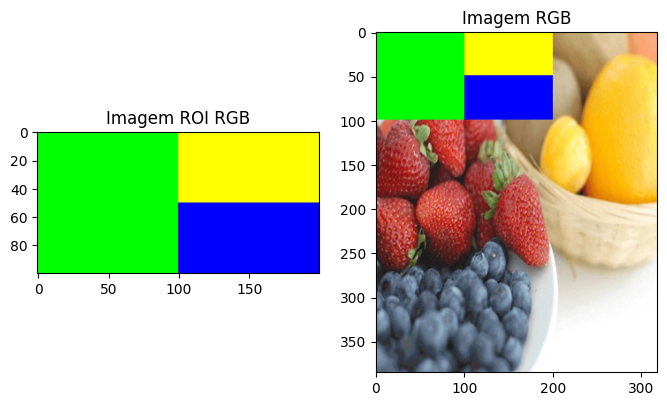

In [21]:
# exibindo imagens no padrão RGB com a biblioteca matplotlib
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8,5))
ax[0].imshow(img_roi_mod_rgb)
ax[0].set_title('Imagem ROI RGB')
ax[1].imshow(img_mod_rgb)
ax[1].set_title('Imagem RGB')
plt.show();

### 10. Visualização de Detecção de Faces com OpenCV

**Objetivo**

Seu modelo de detecção facial identificou uma face na imagem lenna_250.png e retornou as coordenadas da região detectada, 
```python
# Coordenadas da detecção (x1, y1 = canto superior esquerdo; x2, y2 = canto inferior direito)
x1, y1 = 70, 80
x2, y2 = 200, 190
```

Sua tarefa é visualizar essa detecção desenhando um retângulo delimitador e adicionando um rótulo de identificação.

**Tarefas:**

* Carregue a imagem usando cv2.imread().
* Crie uma cópia da imagem original para preservar os dados.
* Desenhe um retângulo nas coordenadas fornecidas pelo modelo, com as seguintes propriedades:
    * Cor: Vermelho (formato BGR).
    * Espessura: 2 pixels.
* Adicione um rótulo de texto no canto superior esquerdo do retângulo, com:
    * Fonte: cv2.FONT_HERSHEY_SIMPLEX.
    * Tamanho: 0.5.
    * Cor: Vermelho (mesma cor do retângulo).
    * Espessura: 2 pixels.
* Exiba a imagem.

In [22]:
# Carrega a imagem
image = cv2.imread(path_pasta_imagem+'lenna_250.png')

# Copia da imagem para desenho
img_draw = image.copy()

In [23]:
# Coordenadas da detecção (x1, y1 = canto superior esquerdo; x2, y2 = canto inferior direito)
x1, y1 = 70, 80
x2, y2 = 200, 190

# inserindo o retangulo
cv2.rectangle(img_draw,(x1,y1),(x2,y2),(0,0,255),2)

# inserindo o texto --> Rosto identificado
cv2.putText(img_draw,'Rosto identicado', (20,20), cv2.FONT_HERSHEY_SIMPLEX, 0.5,(0,0,255), 2)

cv2.imshow('Lenna', img_draw)
cv2.waitKey(0)
cv2.destroyAllWindows()

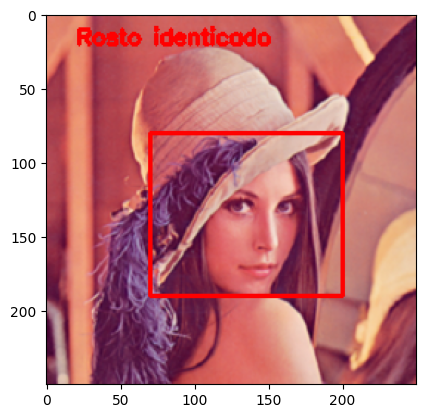

In [24]:
# imagem rgb
img_rgb = cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb);